# Noisy Analog Simulation

Relaxation can remove an excitation before it travels across a spin chain. To
study this competition between transport and loss, we follow an excitation
through a **20-site XY chain** and compare its motion at several relaxation
rates. The occupation heatmaps show where the excitation travels, while the
total occupation tells us how much survives.

This guide extends the analog example in {doc}`quickstart` using only the
standard YAQS installation. YAQS represents the state as a matrix product state
(MPS) and simulates noise with the tensor jump method (TJM), averaging
independent quantum-jump trajectories. Run the cells in order in a notebook. In
a script, put execution inside an `if __name__ == "__main__":` guard, as shown
in {doc}`simulator_initialization`.

## 1. Build the Hamiltonian

The XY model lets an excitation move between neighboring spins without changing
the total number of excitations. With open ends and the coefficients below, its
Hamiltonian is

$$
H=-\frac{1}{2}\sum_{i=0}^{L-2}(X_iX_{i+1}+Y_iY_{i+1}).
$$

In [1]:
from mqt.yaqs import Hamiltonian

length = 20
hamiltonian = Hamiltonian.heisenberg(length, Jx=0.5, Jy=0.5, Jz=0.0)

Setting `Jz=0` removes the ZZ interaction from the Heisenberg model. The default
boundary condition is open, so sites 0 and 19 have one neighbor each. Because
the Hamiltonian conserves excitation, a noiseless run gives us a baseline
against which to measure relaxation.

We use $\hbar=1$ and set the excitation-hopping amplitude to one. Time is
measured in its inverse units. See {doc}`hamiltonians` for other built-in
models, custom terms, and boundary conditions.

## 2. Prepare one localized excitation

To see the excitation spread, start every spin in $|0\rangle$ except the spin at
site 10, which starts in $|1\rangle$. Each character of `basis_string` specifies
the state of the corresponding site, starting at site 0.

In [2]:
from mqt.yaqs import State

center = length // 2
basis = "0" * center + "1" + "0" * (length - center - 1)
state = State(length, initial="basis", basis_string=basis)

`State` uses an MPS by default. A single excitation keeps entanglement modest,
so this example is inexpensive compared with a general interacting state on 20
sites. For other initial states and representations, see
{doc}`state_initialization` and {doc}`representation_comparison`.

## 3. Choose observables, times, and accuracy

The spatial dynamics require one observable per site. We use $Z_i$, whose
expectation gives the occupation through
$\langle n_i\rangle=(1-\langle Z_i\rangle)/2$.

In [3]:
from mqt.yaqs import AnalogSimParams, Observable

params = AnalogSimParams(
    observables=[Observable("z", site) for site in range(length)],
    elapsed_time=3.0,
    dt=0.25,
    num_traj=32,
    preset="fast",
    random_seed=7,
)

These settings sample 13 times from $t=0$ to $t=3$, long enough to see the
excitation spread away from the center. Time sampling is enabled by default, and
`elapsed_time` must be an integer multiple of `dt`.

The `fast` preset sets numerical tolerances for a quick example. We override its
trajectory budget with `num_traj=32`, so each noisy run averages 32
trajectories; the noiseless calculation needs only one. Increasing this budget
reduces sampling error, while timestep and MPS truncation errors require
separate convergence checks.

`random_seed` fixes the jump random streams for repeat runs with the same
configuration. It does not improve accuracy. See {doc}`simulation_parameters`
for presets, overrides, and convergence settings.

## 4. Define relaxation

Relaxation competes with the motion generated by the Hamiltonian. The `lowering`
channel turns $|1\rangle$ into $|0\rangle$ without adding new excitations. Give
every site the same relaxation rate $\gamma$:

In [4]:
from mqt.yaqs import NoiseModel

relaxation_rate = 4.0
noise = NoiseModel([
    {"name": "lowering", "sites": [site], "strength": relaxation_rate}
    for site in range(length)
])

For analog evolution, `strength` is a Lindblad rate, with units of inverse time.
YAQS forms the jump operator $\sqrt{\gamma}\,|0\rangle\langle1|$ internally;
supply $\gamma$, not its square root.

The corresponding lifetime is $1/\gamma$. At $\gamma=4$, loss occurs on a
shorter timescale than hopping between sites. For site-dependent rates, other
channels, custom operators, and distribution-valued strengths, see
{doc}`realistic_noise_models`.

## 5. Run the noiseless and noisy cases

Initialize the simulator separately, then pass the state, Hamiltonian, and
parameters to `run`. Omit the noise model for the noiseless baseline.

In [5]:
from mqt.yaqs import Simulator

simulator = Simulator(show_progress=False)
noiseless = simulator.run(state, hamiltonian, params)
noisy = simulator.run(state, hamiltonian, params, noise)

Parallel execution remains enabled by default. `show_progress=False` keeps the
documentation quiet; omit it to see progress. Execution and worker options are
explained in {doc}`simulator_initialization`.

## 6. Read the results

`expectation_values` follows the order of the supplied observables. Here, row
$i$ contains $\langle Z_i\rangle$ and columns follow `times`. Convert the
expectations to an array of occupations:

In [6]:
import numpy as np

times = np.asarray(noisy.times)
occupation = (1 - np.asarray(noisy.expectation_values)) / 2
print(occupation.shape)

(20, 13)


The shape is `(20, 13)`: sites by sampled times. At $t=0$, only site 10 has
occupation one. In noisy runs, each entry is a trajectory average, rather than a
single measurement outcome. `noisy.trajectories` retains the per-trajectory
observable data when you need to examine sampling fluctuations.

## 7. Compare four relaxation strengths

The relaxation lifetime determines how long the excitation can propagate before
loss. To compare that timescale with the transport dynamics, keep the model and
numerical settings fixed and add rates between the two runs above:

In [7]:
rates = [0.0, 0.5, 1.5, relaxation_rate]
results = {0.0: noiseless, relaxation_rate: noisy}
for rate in rates[1:-1]:
    rate_noise = NoiseModel([
        {"name": "lowering", "sites": [site], "strength": rate}
        for site in range(length)
    ])
    results[rate] = simulator.run(state, hamiltonian, params, rate_noise)

occupations = np.stack([
    (1 - np.asarray(results[rate].expectation_values)) / 2
    for rate in rates
])

The nonzero rates give lifetimes of $2$, $2/3$, and $1/4$ in the time units used
here. The heatmaps below compare how far the excitation spreads before its
occupation decays. All panels use one square-root color scale to keep small
occupations visible, with no normalization by the remaining excitation.

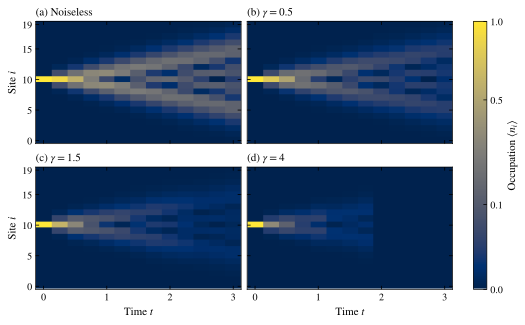

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.linewidth": 0.7,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "lines.linewidth": 1.6,
    "figure.constrained_layout.use": True,
    "savefig.dpi": 180,
})
fig, axes = plt.subplots(2, 2, figsize=(7.2, 4.4), sharex=True, sharey=True)
for ax, values, rate, panel in zip(
    axes.flat, occupations, rates, "abcd", strict=True,
):
    image = ax.pcolormesh(
        times, np.arange(length), values, shading="auto", cmap="cividis",
        norm=PowerNorm(0.5, vmin=0, vmax=1), rasterized=True,
    )
    label = "Noiseless" if rate == 0 else rf"$\gamma={rate:g}$"
    ax.set_title(f"({panel}) {label}", loc="left", fontsize=11)
    ax.set(xticks=[0, 1, 2, 3], yticks=[0, 5, 10, 15, 19])
for ax in axes[-1]:
    ax.set_xlabel(r"Time $t$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"Site $i$")
fig.colorbar(image, ax=axes.ravel().tolist(),
             label=r"Occupation $\langle n_i\rangle$", ticks=[0, 0.1, 0.5, 1])
plt.show()

**Excitation transport under uniform relaxation.** Without noise, the excitation
spreads outward and forms an interference pattern. Increasing the relaxation
rate suppresses occupation at later times and more distant sites. At $\gamma=4$,
most of the excitation is lost before it travels far from the center.

The fading pattern does not imply slower propagation. Conditioned on no jump,
the excitation follows the noiseless spatial dynamics because this Hamiltonian
conserves excitation and the loss rate is uniform. Site-dependent relaxation or
a different channel can change that profile. This time window mainly shows
outward propagation; longer runs can also show reflections from the open ends.

## 8. Check the total excitation

The heatmaps combine spreading with loss. Summing occupation over sites removes
the spatial information and isolates the survival probability. Since the initial
state has exactly one excitation and every site has the same relaxation rate,
the ensemble mean obeys

$$
N(t)=\sum_i\langle n_i(t)\rangle=e^{-\gamma t}.
$$

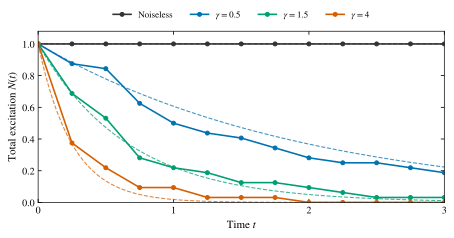

In [9]:
total_excitation = occupations.sum(axis=1)
fine_times = np.linspace(times[0], times[-1], 200)
colors = ["0.2", "#0072B2", "#009E73", "#D55E00"]
fig, ax = plt.subplots(figsize=(6.2, 3.2))
for rate, values, color in zip(rates, total_excitation, colors, strict=True):
    ax.plot(times, values, "o-", color=color, markersize=4,
            label="Noiseless" if rate == 0 else rf"$\gamma={rate:g}$")
    ax.plot(fine_times, np.exp(-rate * fine_times), "--", color=color,
            linewidth=1.1, alpha=0.75)
ax.set(xlabel=r"Time $t$", ylabel=r"Total excitation $N(t)$",
       xlim=(0, 3), ylim=(0, 1.08), xticks=[0, 1, 2, 3])
ax.legend(ncols=4, loc="lower center", bbox_to_anchor=(0.5, 1.02))
plt.show()

**Excitation survival compared with the decay law.** Markers show the YAQS
estimates, and dashed lines show $e^{-\gamma t}$. At $t=3$, the exact survival
probabilities are one without noise and about $0.22$, $0.011$, and
$6\times10^{-6}$ for the three nonzero rates.

Each noisy trajectory either retains its excitation or loses it to a jump. With
only 32 trajectories, the estimated survival fraction changes in steps and may
reach zero while the exact mean is still positive. Finite sampling can also make
curves for different rates cross. Increase `num_traj` to reduce these
fluctuations; the sampling error decreases as $1/\sqrt{\mathtt{num\_traj}}$.

Together, the two figures distinguish loss from redistribution along the chain.
Uniform relaxation reduces the chance of finding the excitation, while surviving
excitations retain the coherent transport pattern. This conclusion and the decay
law rely on uniform loss and excitation-conserving dynamics. The noiseless total
also checks conservation, but that check alone cannot establish the accuracy of
the spatial dynamics.

## Accuracy and other options

Before using a larger or more demanding model, check convergence separately:

| Change                              | What to check                                                                                                                                |
| ----------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------- |
| Increase `num_traj`                 | Whether noisy observables stabilize within sampling uncertainty.                                                                             |
| Reduce `dt` at fixed duration       | Whether the dynamics stabilize with a finer evolution step.                                                                                  |
| Use `balanced` or `accurate`        | Whether tighter truncation and solver settings change the observables. Keep an explicit trajectory budget when comparing numerical settings. |
| Increase `length` or `elapsed_time` | Whether boundaries, entanglement growth, and runtime affect the question being studied.                                                      |

The default MPS evolution uses TDVP updates. To use the BUG integrator, import
`EvolutionMode` from `mqt.yaqs` and set `evolution_mode=EvolutionMode.BUG` in
`AnalogSimParams`. For TDVP, `tdvp_sweeps` adds unitary substeps without
changing the noise timestep. See {doc}`simulation_parameters` for these advanced
choices.

## Related topics

- {doc}`realistic_noise_models` — other channels, custom jumps, and static
  disorder
- {doc}`digital_analog_simulation` — combine analog evolution and digital
  operations
- {doc}`hamiltonians` — built-in, custom, hardware, and time-dependent
  Hamiltonians
- {doc}`representation_comparison` — MPS, statevector, and density matrix
  backends
- {ref}`noise-scheduled-jumps` — deterministic jumps at specified times
- {doc}`ensemble_evolution` — unitary ensemble correlations